# SLIIT IT3051 - Data Mining Project (EV Battery PHM)
## Section C: Imbalance, Relationships & Feature Engineering
### **Assigned Member: Person C**

---
### Instructions for this Notebook:
1. Complete each `# TODO` cell in order using Python and standard data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`).
2. Execute the cells to inspect the output.
3. Answer the guiding viva questions in the **Analysis & Viva Notes** markdown cells.
4. Push your completed notebook to your Git branch.


### 0. Environment Setup
Run this cell to import required packages and set plot aesthetics.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'Arial'

print('Environment initialized successfully!')

Environment initialized successfully!


### Task 1: Task 2 Target Distribution & Class Imbalance
Analyze the class distribution of `battery_failure` (0 = Normal, 1 = Failure). Calculate class counts, percentages, and plot a bar chart.


Battery Failure Class Distribution
----------------------------------
Normal (0):  18616 (93.08%)
Failure (1): 1384 (6.92%)

Class Imbalance Ratio (Normal : Failure): 13.45 : 1


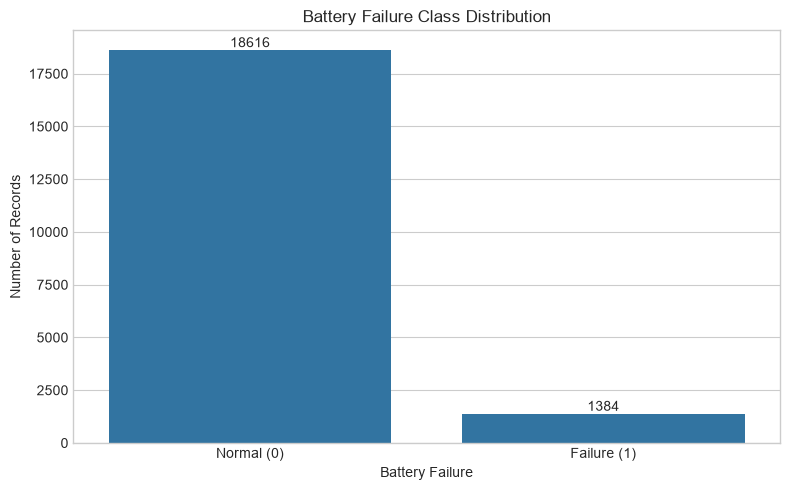

In [8]:
# TODO: Load dataset
df = pd.read_csv('../ev battery_failure  Dataset.csv')

# TODO: Calculate counts and percentage proportions of battery_failure

# Calculate class counts
class_counts = df['battery_failure'].value_counts().sort_index()

# Calculate class percentages
class_percentages = (
    df['battery_failure'].value_counts(normalize=True)
    .sort_index() * 100
)

# Calculate imbalance ratio
normal_count = class_counts[0]
failure_count = class_counts[1]
imbalance_ratio = normal_count / failure_count

print("Battery Failure Class Distribution")
print("----------------------------------")
print(f"Normal (0):  {normal_count} ({class_percentages[0]:.2f}%)")
print(f"Failure (1): {failure_count} ({class_percentages[1]:.2f}%)")
print(f"\nClass Imbalance Ratio (Normal : Failure): {imbalance_ratio:.2f} : 1")


# TODO: Plot a bar chart illustrating the class imbalance

# Plot class distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='battery_failure'
)

plt.title('Battery Failure Class Distribution')
plt.xlabel('Battery Failure')
plt.ylabel('Number of Records')
plt.xticks([0, 1], ['Normal (0)', 'Failure (1)'])

# Add count labels above bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


**Analysis & Viva Preparation Notes (Fill this in after running your code):**
- What is the exact class imbalance ratio (Normal vs Failure)?
- Why is standard classification accuracy a flawed evaluation metric for this task? Which metrics should we use instead?


### Task 2: Feature-Target Correlation & Multicollinearity
Compute Pearson correlation coefficients between key physical variables and both targets. Visualize the relationships with a correlation heatmap.


In [9]:
# TODO: Select key physical telemetry features and dual targets

numeric_df = df.select_dtypes(include=np.number)

# TODO: Calculate correlation matrix and display a heatmap

corr_matrix = numeric_df.corr()

print("Number of numerical features:", numeric_df.shape[1])
print("Correlation matrix shape:", corr_matrix.shape)

Number of numerical features: 60
Correlation matrix shape: (60, 60)


In [10]:
failure_corr = (
    corr_matrix['battery_failure']
    .drop('battery_failure')
    .sort_values(key=abs, ascending=False)
)

print("Top correlations with Battery Failure:")
print(failure_corr.head(15))

Top correlations with Battery Failure:
thermal_runaway_risk               0.390162
thermal_health_score              -0.382988
capacity_loss_percent              0.313285
battery_health_percent            -0.312144
state_of_health                   -0.309538
predicted_remaining_life_cycles   -0.300278
internal_resistance                0.289066
cell_temperature_max               0.286755
cell_temperature_avg               0.265972
charge_efficiency                 -0.259309
discharge_efficiency              -0.251558
battery_stress_index               0.239195
aging_score                        0.229643
vehicle_age_years                  0.219600
manufacturing_year                -0.216856
Name: battery_failure, dtype: float64


In [11]:
rul_corr = (
    corr_matrix['predicted_remaining_life_cycles']
    .drop('predicted_remaining_life_cycles')
    .sort_values(key=abs, ascending=False)
)

print("Top correlations with Predicted Remaining Life Cycles:")
print(rul_corr.head(15))

Top correlations with Predicted Remaining Life Cycles:
capacity_loss_percent    -0.891103
battery_health_percent    0.890854
state_of_health           0.880991
aging_score              -0.862494
internal_resistance      -0.818706
vehicle_age_years        -0.774202
manufacturing_year        0.769973
charge_efficiency         0.750321
discharge_efficiency      0.694694
cycle_count              -0.605302
battery_stress_index     -0.572897
odometer_km              -0.533843
battery_failure          -0.300278
remaining_capacity        0.235109
temperature_variance     -0.175900
Name: predicted_remaining_life_cycles, dtype: float64


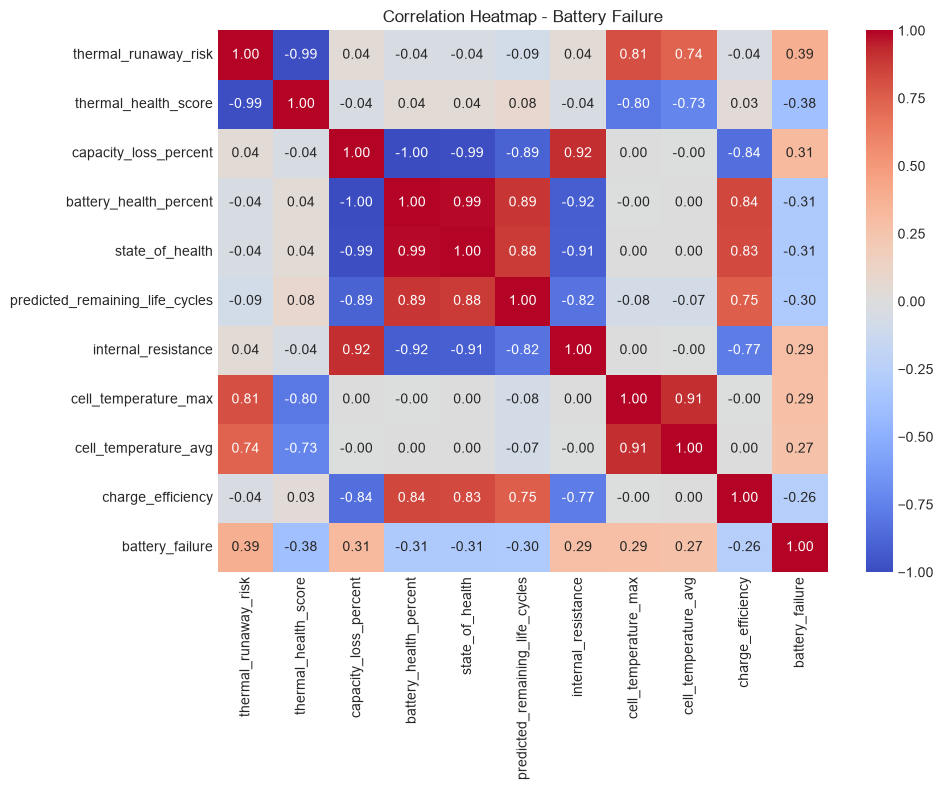

In [12]:
# Top 10 features correlated with battery failure
top_failure_features = failure_corr.head(10).index.tolist()
failure_heatmap_cols = top_failure_features + ['battery_failure']

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[failure_heatmap_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap - Battery Failure')
plt.tight_layout()
plt.show()

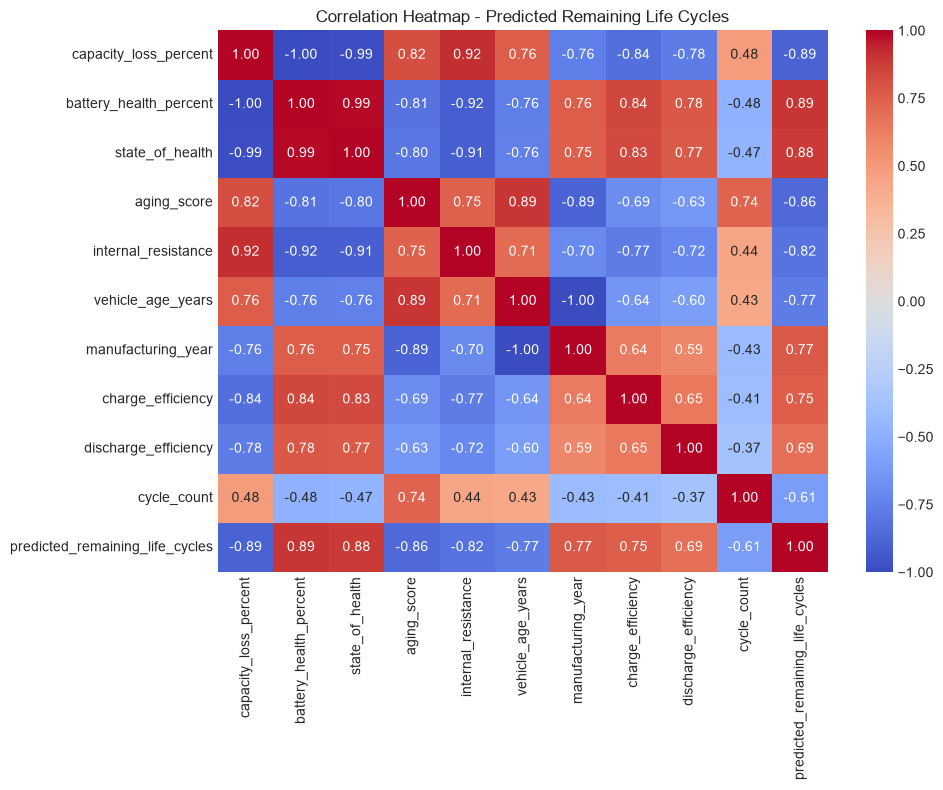

In [13]:
# Top 10 features correlated with remaining life cycles
top_rul_features = rul_corr.head(10).index.tolist()
rul_heatmap_cols = top_rul_features + ['predicted_remaining_life_cycles']

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[rul_heatmap_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap - Predicted Remaining Life Cycles')
plt.tight_layout()
plt.show()

In [14]:
# Remove target columns before checking feature-to-feature correlation
feature_df = numeric_df.drop(
    columns=[
        'battery_failure',
        'predicted_remaining_life_cycles'
    ],
    errors='ignore'
)

feature_corr = feature_df.corr().abs()

# Take only the upper triangle so pairs are not duplicated
upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

# Find highly correlated feature pairs
high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
)

high_corr_pairs.columns = [
    'Feature_1',
    'Feature_2',
    'Correlation'
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs['Correlation'] >= 0.85
    ]
    .sort_values('Correlation', ascending=False)
)

print("Highly Correlated Feature Pairs (|r| >= 0.85)")
print("------------------------------------------------")
print(high_corr_pairs.to_string(index=False))

Highly Correlated Feature Pairs (|r| >= 0.85)
------------------------------------------------
                  Feature_1             Feature_2  Correlation
     battery_health_percent capacity_loss_percent     1.000000
         manufacturing_year     vehicle_age_years     0.995283
            state_of_health capacity_loss_percent     0.989765
     battery_health_percent       state_of_health     0.989756
           cell_voltage_std     voltage_imbalance     0.987412
       thermal_runaway_risk  thermal_health_score     0.986754
average_ambient_temperature   maximum_temperature     0.979392
average_ambient_temperature   minimum_temperature     0.973845
       battery_capacity_kwh    remaining_capacity     0.960995
        maximum_temperature   minimum_temperature     0.953562
          last_service_days     maintenance_score     0.939095
          fast_charge_ratio     slow_charge_ratio     0.925611
     battery_health_percent   internal_resistance     0.918540
        internal_resist

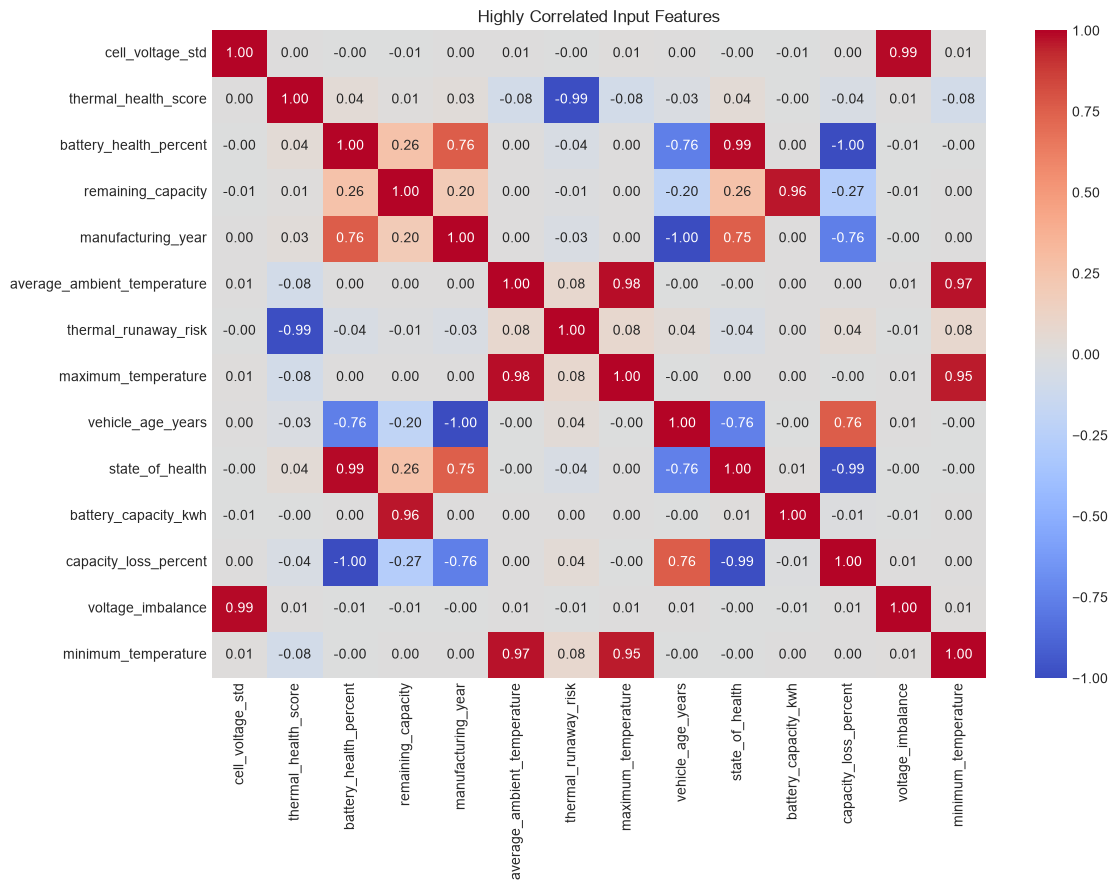

In [15]:
# Get features involved in the strongest correlated pairs
top_pairs = high_corr_pairs.head(10)

high_corr_features = list(set(
    top_pairs['Feature_1'].tolist() +
    top_pairs['Feature_2'].tolist()
))

if high_corr_features:
    plt.figure(figsize=(12, 9))

    sns.heatmap(
        df[high_corr_features].corr(),
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0
    )

    plt.title('Highly Correlated Input Features')
    plt.tight_layout()
    plt.show()
else:
    print("No feature pairs with |r| >= 0.85 were found.")

**Analysis & Viva Preparation Notes (Fill this in after running your code):**
- Which physical variables show the strongest positive or negative correlation with RUL?
- Which variables correlate most strongly with battery failure?
- Did you detect multicollinear feature pairs (|r| > 0.90)? What are they?


### Task 3: Bivariate Physical Discrimination (Normal vs Failure)
Create comparative boxplots comparing normal vs failed batteries across `internal_resistance`, `cell_temperature_max`, and `voltage_imbalance`.


Features selected for boxplot analysis:
['battery_health_percent', 'state_of_health', 'capacity_loss_percent', 'internal_resistance', 'cycle_count', 'cell_temperature_avg']


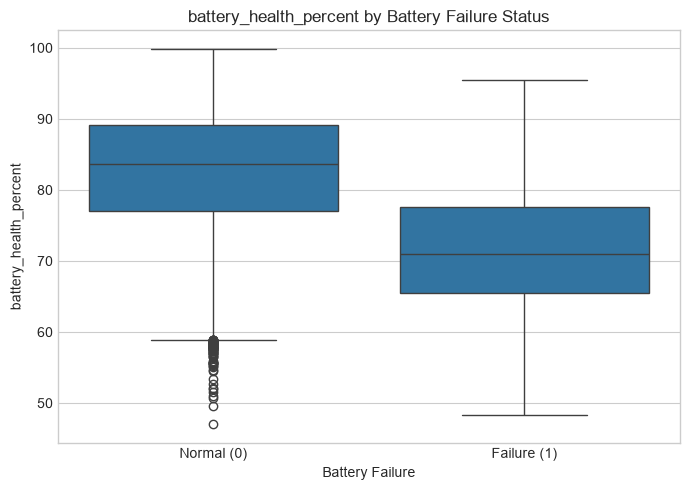

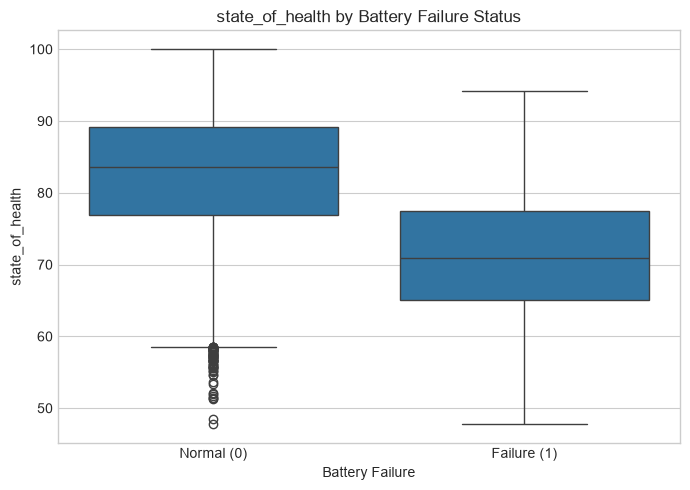

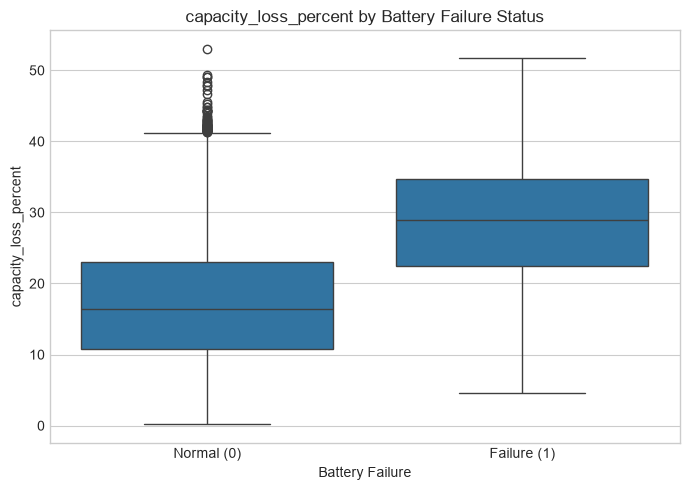

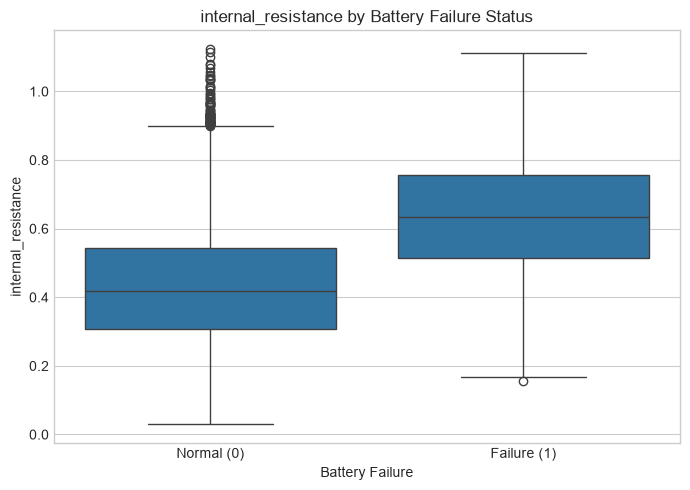

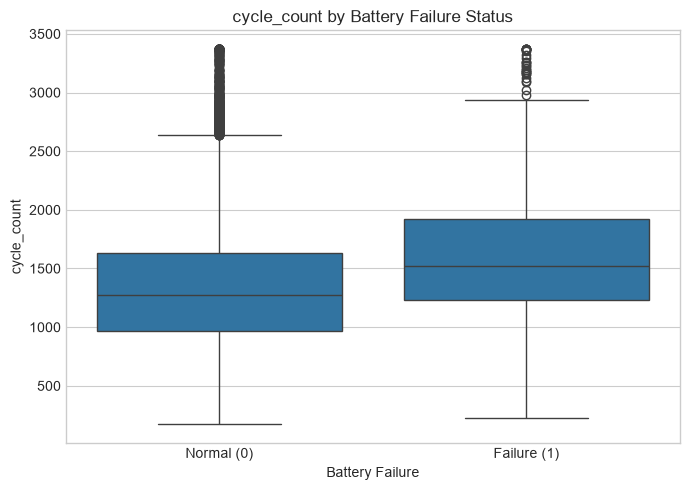

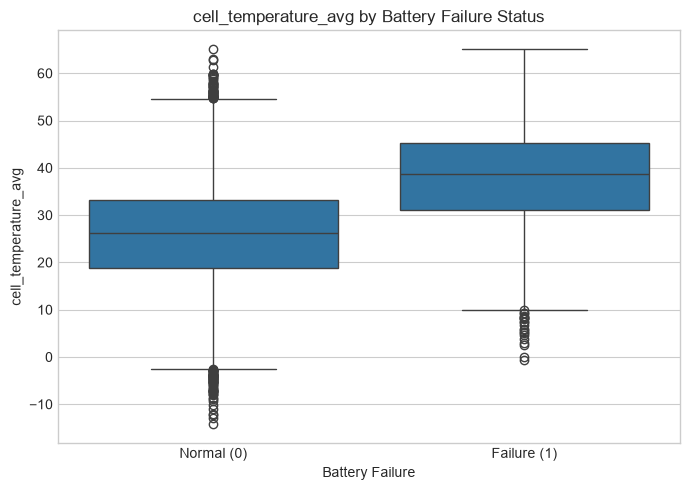

In [16]:
# TODO: Create boxplots comparing normal vs failure across internal_resistance, cell_temperature_max, and voltage_imbalance

boxplot_features = [
    'battery_health_percent',
    'state_of_health',
    'capacity_loss_percent',
    'internal_resistance',
    'cycle_count',
    'cell_temperature_avg'
]

# Only keep columns that actually exist
boxplot_features = [
    col for col in boxplot_features
    if col in df.columns
]

print("Features selected for boxplot analysis:")
print(boxplot_features)

for feature in boxplot_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x='battery_failure',
        y=feature
    )

    plt.title(f'{feature} by Battery Failure Status')
    plt.xlabel('Battery Failure')
    plt.ylabel(feature)

    plt.xticks(
        [0, 1],
        ['Normal (0)', 'Failure (1)']
    )

    plt.tight_layout()
    plt.show()

**Analysis & Viva Preparation Notes (Fill this in after running your code):**
- How do internal resistance and max temperature differ between normal and failed batteries?
- Does voltage imbalance show clear physical separation between the two classes?


### Task 4: Stage 3 Domain Feature Engineering
Derive 4 domain-specific electrochemical features:
1. Thermal Gradient: `temp_delta = cell_temperature_max - cell_temperature_avg`
2. C-Rate Proxy: `c_rate_proxy = average_charge_power_kw / battery_capacity_kwh`
3. Cell Degradation Index: `cell_voltage_spread = cell_voltage_std / (cell_voltage_avg + 1e-5)`
4. Driving Usage Severity: `stress_index = aggressive_acceleration_score * hard_braking_score`


cell_temperature_avg: True
cell_temperature_max: True
battery_health_percent: True
capacity_loss_percent: True
charge_efficiency: True
discharge_efficiency: True
internal_resistance: True
cycle_count: True
Created engineered features:
['temperature_spread', 'efficiency_gap', 'health_loss_interaction', 'resistance_per_1000_cycles']
                              count       mean       std       min       25%  \
temperature_spread          18318.0  13.550197  4.881512  5.000000  9.320000   
efficiency_gap              18426.0   1.121721  0.786439  0.000000  0.470000   
health_loss_interaction     18192.0  14.007845  5.450503  0.199600  9.930076   
resistance_per_1000_cycles  18466.0   0.355972  0.150992  0.015408  0.247449   

                                  50%        75%        max  
temperature_spread          13.620000  17.747500  22.000000  
efficiency_gap               0.980000   1.650000   3.760000  
health_loss_interaction     14.156151  18.255591  24.999991  
resistance_per_100

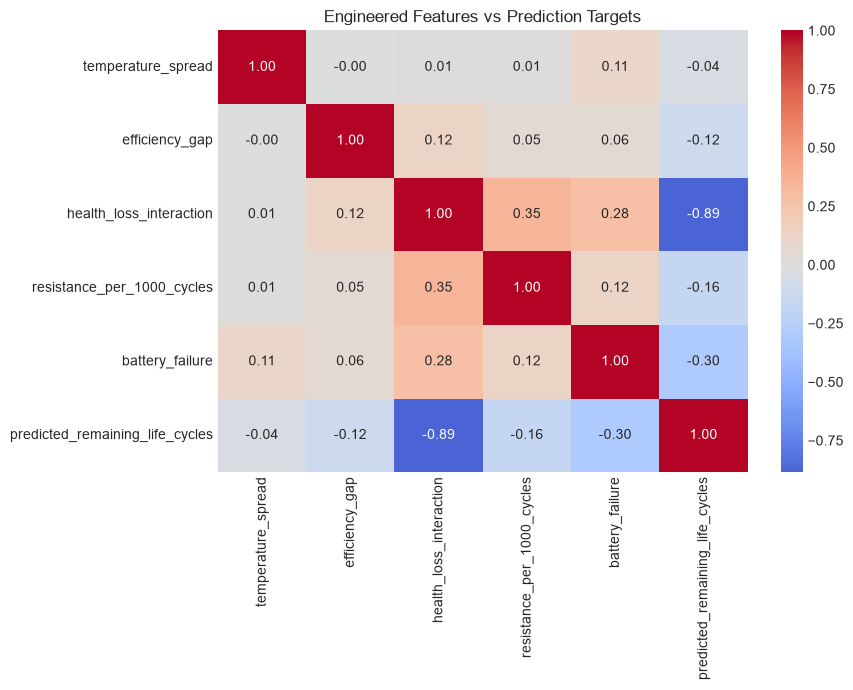

In [23]:
required_cols = [
    'cell_temperature_avg',
    'cell_temperature_max',
    'battery_health_percent',
    'capacity_loss_percent',
    'charge_efficiency',
    'discharge_efficiency',
    'internal_resistance',
    'cycle_count'
]

for col in required_cols:
    print(f"{col}: {col in df.columns}")

# TODO: Create the 4 engineered features in the dataframe

# 1. Temperature Spread
# Larger spread may indicate uneven thermal behaviour.
df['temperature_spread'] = (
    df['cell_temperature_max'] -
    df['cell_temperature_avg']
)

# 2. Efficiency Gap
# Difference between charge and discharge efficiency.
df['efficiency_gap'] = (
    df['charge_efficiency'] -
    df['discharge_efficiency']
).abs()

# 3. Health-Loss Interaction
# Combines current battery health with accumulated capacity loss.
df['health_loss_interaction'] = (
    df['battery_health_percent'] *
    df['capacity_loss_percent']
) / 100

# 4. Resistance per 1000 Cycles
# Relates internal resistance to accumulated battery usage.
df['resistance_per_1000_cycles'] = (
    df['internal_resistance'] /
    (df['cycle_count'] + 1)
) * 1000

engineered_features = [
    'temperature_spread',
    'efficiency_gap',
    'health_loss_interaction',
    'resistance_per_1000_cycles'
]

print("Created engineered features:")
print(engineered_features)



# TODO: Display descriptive statistics of the new features

# Check engineered feature statistics

print(df[engineered_features].describe().T)

print("\nMissing values:")
print(df[engineered_features].isnull().sum())

print("\nInfinite values:")
print(
    np.isinf(df[engineered_features])
    .sum()
)

# TODO: Compute correlation between engineered features and both targets

analysis_cols = engineered_features + [
    'battery_failure',
    'predicted_remaining_life_cycles'
]

engineered_corr = df[analysis_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    engineered_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Engineered Features vs Prediction Targets')
plt.tight_layout()
plt.show()


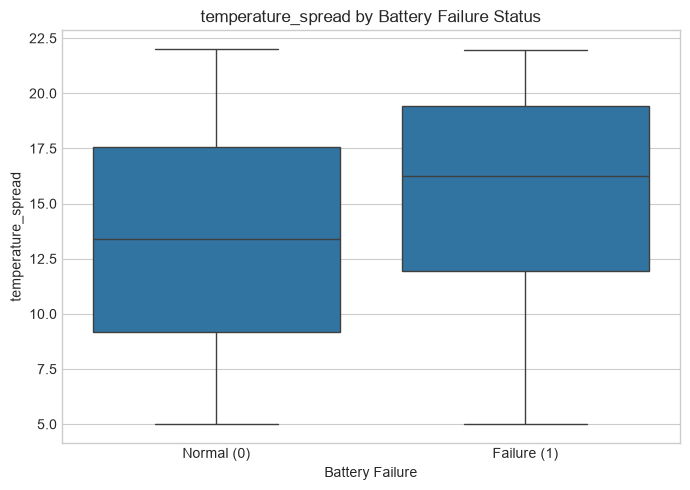

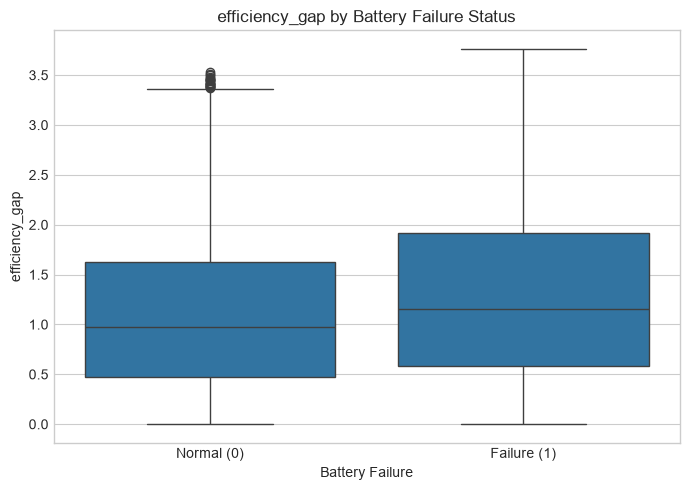

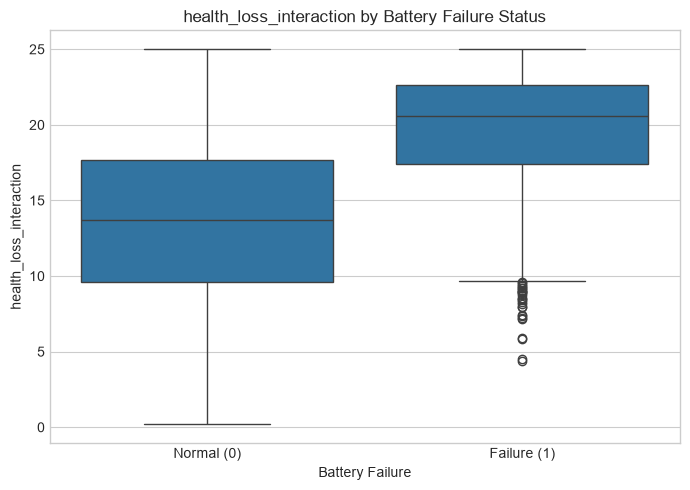

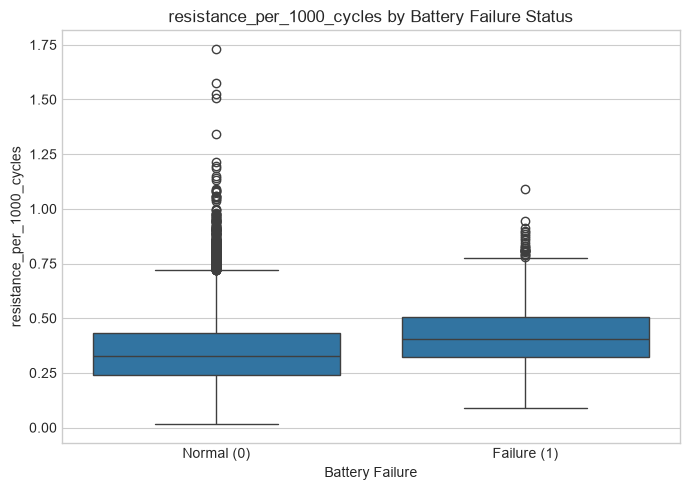

In [24]:
for feature in engineered_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x='battery_failure',
        y=feature
    )

    plt.title(f'{feature} by Battery Failure Status')
    plt.xlabel('Battery Failure')
    plt.ylabel(feature)

    plt.xticks(
        [0, 1],
        ['Normal (0)', 'Failure (1)']
    )

    plt.tight_layout()
    plt.show()

**Analysis & Viva Preparation Notes (Fill this in after running your code):**
- Explain the electrochemical or mechanical rationale behind each of the 4 engineered features.
- Did any of the engineered features exhibit notable correlation with either failure risk or RUL?


## Person C - Summary

### Class Imbalance
The `battery_failure` target contains 18,616 normal observations (93.08%)
and 1,384 failure observations (6.92%), resulting in an imbalance ratio
of approximately 13.45:1. Therefore, classification accuracy alone may
be misleading for this task.

### Relationship Analysis
Correlation analysis was performed to investigate relationships between
numerical features and the two prediction targets:
`battery_failure` and `predicted_remaining_life_cycles`.

Feature-to-feature correlations were also examined to identify potential
multicollinearity and redundant numerical information.

### Distribution Analysis
Boxplots were used to compare selected battery characteristics between
normal and failed batteries. These plots help identify differences in
feature distributions, medians, spread, and potential outliers.

### Feature Engineering
Four domain-informed candidate features were created:

1. `temperature_spread`
2. `efficiency_gap`
3. `health_loss_interaction`
4. `resistance_per_1000_cycles`

These features represent thermal variation, charge/discharge efficiency
imbalance, interaction between battery health and capacity loss, and
internal resistance relative to accumulated cycle usage.

The engineered features were validated for missing and infinite values
and analyzed against the prediction targets.

### Conclusion
The analysis identified a substantial class imbalance in the battery
failure target and explored important relationships within the battery
data. The four engineered features provide additional representations
of battery condition and degradation for subsequent model development.
Their actual predictive value should be assessed during model training
and validation.